# <center>Assignment 1 2026</center>

<center>Author: Lewei Xu (23709058)</center>

## Part 1 Softmax Regression

In this task, we will implement a Softmax Regression classifier using gradient descent optimisation from scratch. The goal of the model is to classify hand-written numbers from the MNIST dataset into 1 of 10 classes (0, 1, 2, 3, 4, 5, 6, 7, 8, 9).

Softmax Regression is a generalisation of logistic regression to the multiclass case. It estimates the probability of $\mathbf{x}$ belonging to class $k$ as,

$$\hat{p}_k = \frac{\exp(s_k(\mathbf{x}))}{\sum_{j=1}^{K} \exp(s_j(\mathbf{x}))},$$

where $K$ is the total number of classes and $s_k(\mathbf{x}) = (\theta^{(k)})^{\intercal} \mathbf{x}$.

The cost function for Softmax Regression is the cross-entropy loss, which is given by,

$$J(\theta) = - \frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log \left( \hat{p}_k^{(i)} \right),$$

where $y_k^{(i)}$ is the target probability that the $i^{th}$ instance belongs to class $k$. Then $\partial J / \partial \boldsymbol{\theta}^{(k)}$ is given by,

$$\frac{\partial J}{\partial \boldsymbol{\theta}^{(k)}} = \frac{1}{m} \sum_{i=1}^{m} \left( \hat{p}_k^{(i)} - y_k^{(i)} \right) \mathbf{x}^{(i)}.$$

### Step 1: Load The Dataset

First, we will load the dataset using `sklearn.datasets.fetch_openml`.

In [19]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

### Step 2: Inspect The Dataset

The MNIST dataset contains 70,000 images of handwritten digits (zero to nine). The digits have been size-normalized and centered in a fixed-size image. Each image is 28x28 pixels, resulting in 784 numerical features, values ranging from 0-255 representing the grayscale intensity, and the target data consists of an integer between 0-9. (Source: https://www.openml.org/search?type=data&sort=runs&id=554&status=active)

We can verify this checking the shape and type of `X` and `y` imported above and also display some examples from the dataset

In [20]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X dtype: {X.dtype}")
print(f"y dtype: {y.dtype}")
print(f"X[:5]: {X[:5]}")
print(f"y[:5]: {y[:5]}")
print(f"Unique labels: {sorted(list(set(y)))}")

X shape: (70000, 784)
y shape: (70000,)
X dtype: int64
y dtype: object
X[:5]: [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
y[:5]: ['5' '0' '4' '1' '9']
Unique labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


As we can see, there are 70,000 images and 70,000 targets, each image conists of 784 features, and each feature is a 64 bit integer. The target `y` consists of 10 classes stored as object (string) type.

### Step 3: Split Data & Inspect Split

To perform train a Softmax Classifier on this dataset, we will first split he dataset into 70% training, 15% validation and 15% for testing, then we will inspect the distribution without stratification to determine if we need to stratify the dataset.

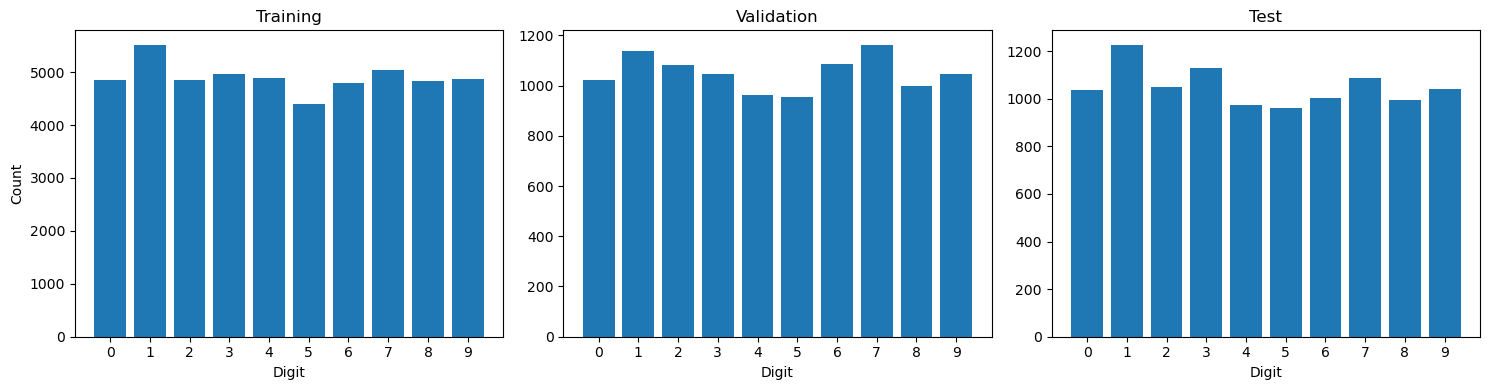

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, train_size=0.5, random_state=42)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

datasets = [("Training", y_train), ("Validation", y_val), ("Test", y_test)]

_, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, data) in enumerate(datasets):
    counts = pd.Series(data).value_counts().sort_index()

    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(name)
    axes[i].set_xlabel("Digit")

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

Although the distribution of digits (0-9) is fairly consistent, we still need to stratify the training/validation/test set to ensure that the distribution of target classes in the splits are the same proportion as the original dataset. This is done to prevent bias due to skewed data, or being trained and tested on data that isn't representative of the original data. It also results in more reliable performance metrics. We will now re-initialize the training/validation/test split with stratification.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, train_size=0.5, random_state=42, stratify=y_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (49000, 784)
X_val shape: (10500, 784)
X_test shape: (10500, 784)


### Step 4: Implement Softmax Regression From Scratch

We will now implement the softmax regression classifier from scratch to classify the hand-written numbers. We will use early stopping based on the validation set: stop training when the validation loss stops decreasing. The task sheet did not specify what form of early stopping to use (simply stop when validation loss stops decreasing, or implement patience with best model saving). To be safe, we will implement a more sophisticated patience mechanism and best model saving, with default patience = 10 epochs. The task sheet also does not specify what hyperparemeters to use for the training algorithm, so we will use some typical settings with a learning rate of 0.1 at 1000 epochs.

In [23]:
class SoftmaxRegressionGD:
    def __init__(self, lr=0.1, epochs=1000, patience=10, display_interval=100):
        self.lr = lr
        self.epochs = epochs
        self.patience = patience
        self.display_interval = display_interval
        self.best_theta = None
        self.history = {'train_loss': [], 'val_loss': []}

    def softmax(self, x):
        """Softmax Function"""
        # Should work due to scaling of inputs to 0-1
        return np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

    def loss(self, y_true, y_probs):
        """Loss Function"""
        m = y_true.shape[0]
        return (-1/m) * np.sum(y_true * np.log(y_probs))

    def gradient(self, X, y_true, y_probs):
        """Gradient Function"""
        m = X.shape[0]
        return (1/m) * X.T @ (y_probs - y_true)

    def one_hot_encode(self, y, num_classes):
        """One-Hot Encoding Function"""
        y = y.astype(int)
        return np.eye(num_classes)[y]
    
    def predict(self, X):
        """Predict Function"""
        X_bias = np.insert(X, 0, 1, axis=1)
        probs = self.softmax(X_bias @ self.best_theta)
        return np.argmax(probs, axis=1)

    def train(self, X_train, y_train, X_val, y_val):
        # Initialize theta with zeros with X_train & y_train dimensions
        theta = np.zeros((X_train.shape[1] + 1, len(set(y_train))))

        # Initialize training data
        X_train_bias = np.insert(X_train, 0, 1, axis=1)
        X_val_bias = np.insert(X_val, 0, 1, axis=1)
        Y_train_ohe = self.one_hot_encode(y_train, theta.shape[1])
        Y_val_ohe = self.one_hot_encode(y_val, theta.shape[1])
        
        # Initialize early stopping & history variables
        best_loss = np.infty
        epochs_without_improvement = 0

        # Begin training loop
        for epoch in range(self.epochs):
            logits = X_train_bias @ theta

            train_probs = self.softmax(logits)
            train_loss = self.loss(Y_train_ohe, train_probs)

            val_probs = self.softmax(X_val_bias @ theta)
            val_loss = self.loss(Y_val_ohe, val_probs)

            gradient = self.gradient(X_train_bias, Y_train_ohe, train_probs)
            theta -= self.lr * gradient

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            
            # Early stopping check
            if val_loss < best_loss:
                best_loss = val_loss
                self.best_theta = theta.copy()
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                
            if epochs_without_improvement >= self.patience:
                print(f"Epochs without improvement reached {self.patience}. Best Val Loss: {best_loss:.4f}")
                break
                
            if epoch % self.display_interval == 0:
                print(f"Epoch {epoch}: Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f}")

`SoftmaxRegressionGD` is defined above. We will now train a model using the defined class. To ensure consistent feature contribution and optimization efficiency, we will first scale the `X` features to between 0-1. As we are performing Softmax Regression GD from scratch, we will also avoid using sklearn for scaling, and manually scale the features instead.

In [24]:
# Scale features to 0-1 range for better convergence
range_val = np.max(X_train) - np.min(X_train)
X_train_scaled = X_train / range_val
X_val_scaled = X_val / range_val
X_test_scaled = X_test / range_val

custom_model = SoftmaxRegressionGD() # Initialize with default parameters

custom_model.train(X_train_scaled, y_train, X_val_scaled, y_val)

Epoch 0: Train Loss 2.3026 | Val Loss 2.3026
Epoch 100: Train Loss 0.6036 | Val Loss 0.6138
Epoch 200: Train Loss 0.4844 | Val Loss 0.4961
Epoch 300: Train Loss 0.4354 | Val Loss 0.4481
Epoch 400: Train Loss 0.4071 | Val Loss 0.4208
Epoch 500: Train Loss 0.3882 | Val Loss 0.4027
Epoch 600: Train Loss 0.3744 | Val Loss 0.3896
Epoch 700: Train Loss 0.3637 | Val Loss 0.3796
Epoch 800: Train Loss 0.3550 | Val Loss 0.3717
Epoch 900: Train Loss 0.3479 | Val Loss 0.3652


Before we jump in to plotting the training and validation loss, let's first check the model's various performance metrics (what is a machine learning task without checking the accuracy of the model am I right). As this isn't exactly a part of the assignment task, we will just cheat a little bit and use sklearn's `classification_report`.

In [25]:
from sklearn.metrics import classification_report

# Evaluate on test set
y_pred = custom_model.predict(X_test_scaled)
y_test_int = y_test.astype(int)
print(classification_report(y_test_int, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1035
           1       0.93      0.97      0.95      1181
           2       0.92      0.87      0.89      1049
           3       0.88      0.88      0.88      1071
           4       0.90      0.91      0.91      1024
           5       0.87      0.84      0.85       947
           6       0.93      0.94      0.94      1032
           7       0.93      0.91      0.92      1094
           8       0.86      0.84      0.85      1024
           9       0.86      0.88      0.87      1043

    accuracy                           0.90     10500
   macro avg       0.90      0.90      0.90     10500
weighted avg       0.90      0.90      0.90     10500



Let's now plot the training and validation loss changes over time for the model and see what we observe.

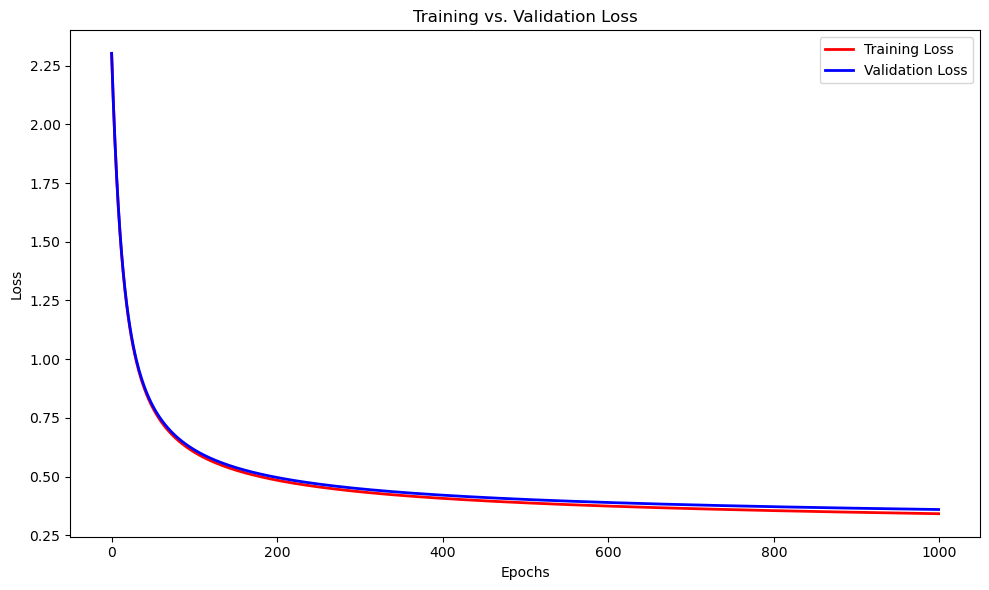

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

epochs_run = range(len(custom_model.history['train_loss']))
plt.plot(epochs_run, custom_model.history['train_loss'], label='Training Loss', color='red', linewidth=2)
plt.plot(epochs_run, custom_model.history['val_loss'], label='Validation Loss', color='blue', linewidth=2)

plt.title('Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Observations**
- Both the training and validation loss curves show a smooth rapid decline in the early epochs before flattening out.
- Shape of the curve is similar to logarithmic decay, which I believe is exactly what we want for gradient descent (GD worked very well).
- Validation loss is consistently higher than training loss (although not by a significant margin).

**Expected?**
- The smoorth logarithmic curve is to be expected especially after the feature scaling to ensure the cost function is a smooth bowl shape.
- We are also using full gradient descent (not SGD or batch-GD) so we won't expect to see any jumps in loss during training.
- Validation loss is expected to be higher than training loss as the model is trying to predict unseen data.

### Step 5: Implement Softmax Regression Using `sklearn`

We will now implement the same model as above but using sklearn and compare the performance between the two. From the plot above, we can see that training and validation loss flattens out at around the 300th epoch.  We will attempt to usee similar settings for sklearn's `LogisticRegression` compared to the custom Softmax Regression by setting `max_iter=1000`, and no regularisation `penalty=None`.

In [27]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression(penalty=None, max_iter=1000, random_state=42)

sk_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, penalty=None, random_state=42)

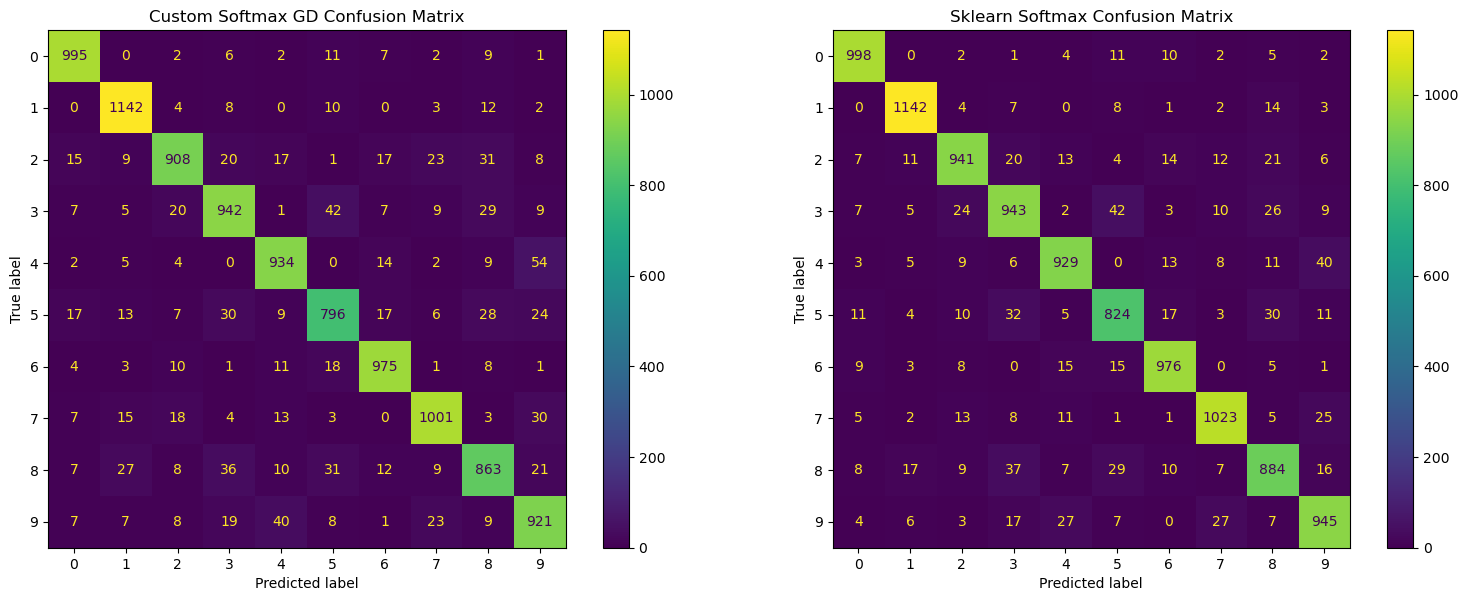

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_sk = sk_model.predict(X_test_scaled)
y_pred_custom = custom_model.predict(X_test_scaled)

y_test_int = y_test.astype(int)
y_pred_sk = y_pred_sk.astype(int)
y_pred_custom = y_pred_custom.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(y_test_int, y_pred_custom, ax=axes[0])
axes[0].set_title("Custom Softmax GD Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test_int, y_pred_sk, ax=axes[1])
axes[1].set_title("Sklearn Softmax Confusion Matrix")

plt.tight_layout()
plt.show()

In [29]:
from sklearn.metrics import classification_report

report_custom = classification_report(y_test_int, y_pred_custom)
report_sk = classification_report(y_test_int, y_pred_sk)

lines_custom = report_custom.split('\n')
lines_sk = report_sk.split('\n')

# Display side-by-side
header_custom = "Custom Softmax Regression GD Model"
header_sk = "Sklearn Logistic Regression Model"
print(f"{header_custom:<55} | {header_sk}")
print("-" * 115)

for c, s in zip(lines_custom, lines_sk):
    print(f"{c.ljust(55)} | {s}")

Custom Softmax Regression GD Model                      | Sklearn Logistic Regression Model
-------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support   |               precision    recall  f1-score   support
                                                        | 
           0       0.94      0.96      0.95      1035   |            0       0.95      0.96      0.96      1035
           1       0.93      0.97      0.95      1181   |            1       0.96      0.97      0.96      1181
           2       0.92      0.87      0.89      1049   |            2       0.92      0.90      0.91      1049
           3       0.88      0.88      0.88      1071   |            3       0.88      0.88      0.88      1071
           4       0.90      0.91      0.91      1024   |            4       0.92      0.91      0.91      1024
           5       0.87      0.84      0.85       947   |    

**Results**
- Both models performed very well, correctly classifying approximately 90% of images. 
- Both models struggled and performed well on the same digits: 
    - Both models performed better on "easy" digits such as 0, 1, 2, 4, 6, 7, with all metrics (precision, recall, f1-score) achieving >0.9.
    - Both performed worse on "harder" digits such as 5, 8 and 9, with precision, recall and f1-score ranging between 0.84-0.88.
    - This is to be expected, as "harder" digits like 5, 8 and 9 are very similar in structure, and it is easy for a relatively simple model like Softmax Regression to confuse them.
    - Some classifcations may not entirely be the model's fault, as some handwritten images are so deformed that even a human may have difficulty classifying them.
- In both models, precision and recall are very similar (balanced) with a macro average of 0.89 and 0.91 for the custom Softmax Regression and sklearn Logistic Regression respectively
    - This means both models aren't biased towards a specific digits.
    - Is this expected? Well, due to the statification performed when splitting the dataset into train, validation and test sets, as well as the nature of softmax itself where the total probability must sum to 1, this result should be highly expected.

We will discuss differences in the model next.

### Step 6: Conclusion & Comments

- The sklearn model slightly outperforms the custom GD model in terms of accuracy. 
    - This is to be expected, as sklearn utilizes the `lbdgs` solver which is a second order optimizer, as well as various other optimizations to basic Softmax Regression.
- As discussed above, both models perform better on "easy" digits and worse on "hard" digits, although the sklearn logistic regression model performs marginally better in both scenarios.
    - As both models are using softmax regression, this similarity is expected.
- Both models maintain a high degree of balance between precision and recall, with little bias towards specific target classes.

## Part 2: Support Vector Machine Regression

In this task, we will investigate how different kernels affect the performance of Support Vecotr Machine (SVM) regression on a synthetic dataset. We will generate our own toy datasets using polynomial functions, then fit SVM regression models with different kernels to the data.

### Part 1: Function To Generate Toy Datasets

First, we will create a function that can generate a random toy *n-degree* polynomial dataset of the form:

$$y = \sum_{k=0}^{n} a_k x^k + \epsilon,$$

where $x \in [-3, 3]$, $a_k \sim \mathcal{U}(0, 1)$, and $\epsilon \sim \mathcal{N}(0, 1)$. The function will take 2 arguments: `degree` and `n_samples=1000`.

In [30]:
import numpy as np

def generate_toy_dataset(degree, n_samples):

    # Set random seed for reproducibility
    np.random.seed(42)

    # Initialize random x & a_k, initalize y_true with zeros
    x = np.random.uniform(-3, 3, n_samples)
    a_k = np.random.uniform(0, 1, degree + 1)
    y_true = np.array([0.0] * n_samples)

    # Calculate y_true 
    for k in range(degree + 1):
        y_true += a_k[k] * (x ** k)

    # Add Gaussian noise to create y
    epsilon = np.random.normal(0, 1, n_samples)
    y = y_true + epsilon
    
    return x, y

Next, let's test the function by constructing 4 plots for degrees 1, 2, 3 and 5.

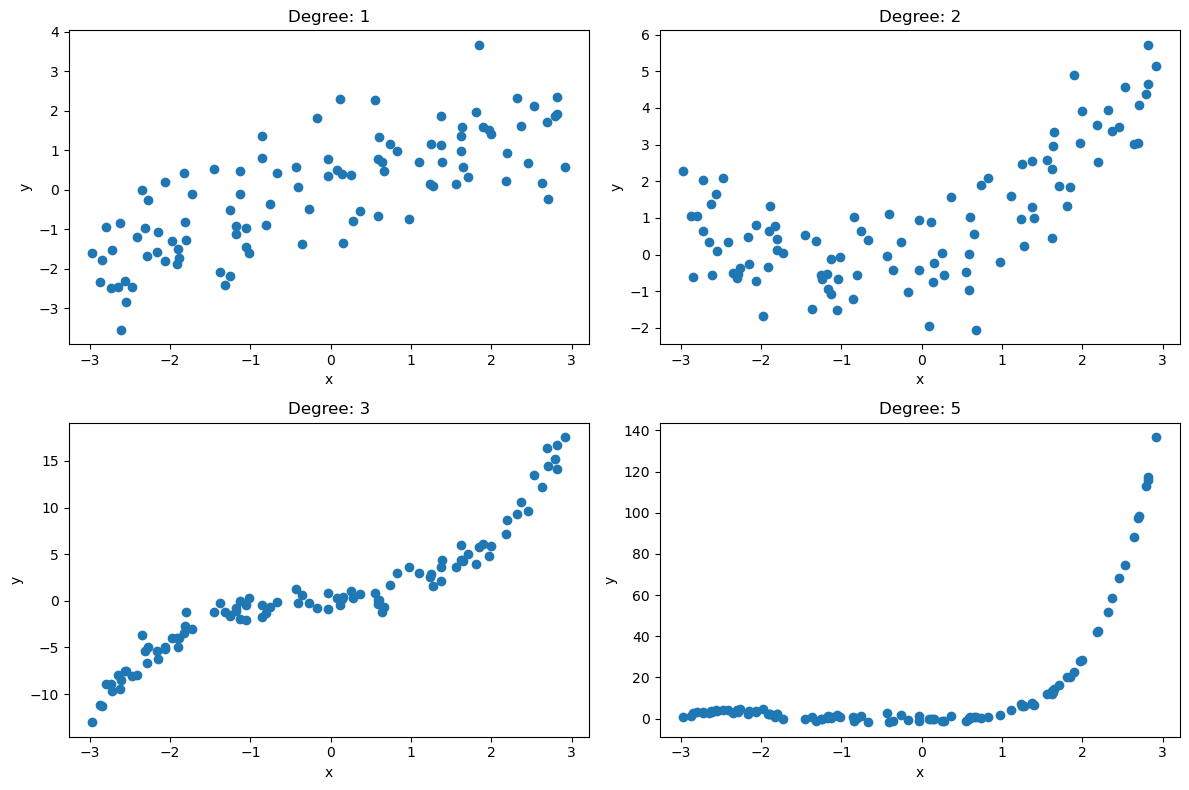

In [31]:
import matplotlib.pyplot as plt

def plot_dataset(degrees_to_test, samples=100):
    plt.figure(figsize=(12, 8))
    
    for i, d in enumerate(degrees_to_test):
        x, y = generate_toy_dataset(degree=d, n_samples=samples)
        
        plt.subplot(2, 2, i + 1)
        plt.scatter(x, y)
        plt.title(f'Degree: {d}')
        plt.xlabel('x')
        plt.ylabel('y')

    plt.tight_layout()
    plt.show()

plot_dataset(degrees_to_test=[1, 2, 3, 5])

### Step 2: Generate Datasets

We will now generate 3 toy datasets: a linear, a quadratic and a cubic dataset. Each dataset will contain 1000 samples. We will then split the dataset for 80% training and 20% testing.

In [32]:
from sklearn.model_selection import train_test_split

# Generate datasets for linear, quadratic, and cubic relationships
x_linear, y_linear = generate_toy_dataset(degree=1, n_samples=1000)
x_quadratic, y_quadratic = generate_toy_dataset(degree=2, n_samples=1000)
x_cubic, y_cubic = generate_toy_dataset(degree=3, n_samples=1000)

# Split each dataset into 80/20 train/test sets
x_linear_train, x_linear_test, y_linear_train, y_linear_test = train_test_split(x_linear, y_linear, test_size=0.2, random_state=42)
x_quadratic_train, x_quadratic_test, y_quadratic_train, y_quadratic_test = train_test_split(x_quadratic, y_quadratic, test_size=0.2, random_state=42)
x_cubic_train, x_cubic_test, y_cubic_train, y_cubic_test = train_test_split(x_cubic, y_cubic, test_size=0.2, random_state=42)

print(f"Linear Train/Test shapes: {x_linear_train.shape}, {x_linear_test.shape}"
      f"\nQuadratic Train/Test shapes: {x_quadratic_train.shape}, {x_quadratic_test.shape}"
      f"\nCubic Train/Test shapes: {x_cubic_train.shape}, {x_cubic_test.shape}")

Linear Train/Test shapes: (800,), (200,)
Quadratic Train/Test shapes: (800,), (200,)
Cubic Train/Test shapes: (800,), (200,)


### Step 3: Fit `sklearn.svm.SVR` To Each Dataset

We will now fit `sklearn.svm.SVR` to each dataset using `linear`, `poly` and `rbf` setting for the kernel argument and inspect the results.

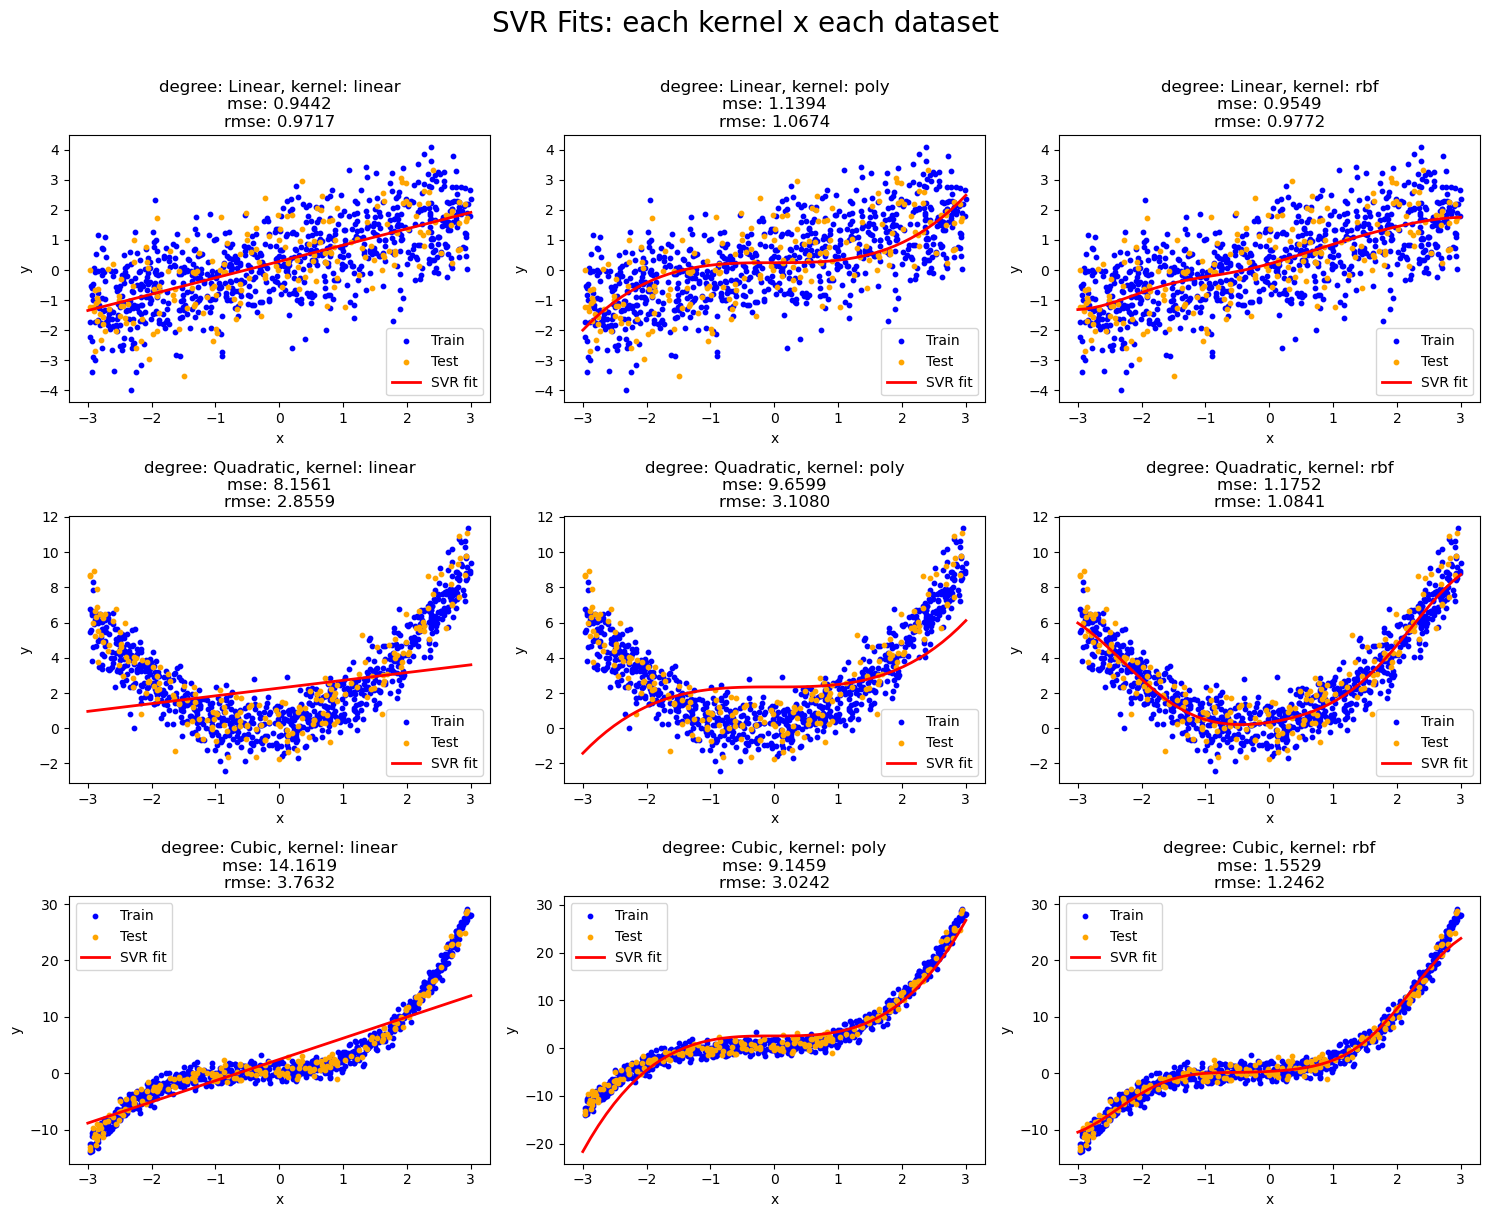

In [33]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

kernels = ['linear', 'poly', 'rbf']
datasets = [
    ('Linear', x_linear_train, y_linear_train, x_linear_test, y_linear_test),
    ('Quadratic', x_quadratic_train, y_quadratic_train, x_quadratic_test, y_quadratic_test),
    ('Cubic', x_cubic_train, y_cubic_train, x_cubic_test, y_cubic_test),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Iterate over each kernel and dataset, fit SVR, calculate MSE, and plot results
for col, kernel in enumerate(kernels):
    for row, (name, x_train, y_train, x_test, y_test) in enumerate(datasets):
        x_train = x_train.reshape(-1, 1)
        x_test = x_test.reshape(-1, 1)

        svr = SVR(kernel=kernel)
        svr.fit(x_train, y_train)
        mse = mean_squared_error(y_test, svr.predict(x_test))

        x_range = np.linspace(-3, 3).reshape(-1, 1)
        y_range_pred = svr.predict(x_range)

        ax = axes[row, col]
        ax.scatter(x_train, y_train, s=10, color='blue', label='Train')
        ax.scatter(x_test, y_test, s=10, color='orange', label='Test')
        ax.plot(x_range, y_range_pred, color='red', linewidth=2, label='SVR fit')
        ax.set_title(f'degree: {name}, kernel: {kernel}\nmse: {mse:.4f}\nrmse: {np.sqrt(mse):.4f}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.legend()

plt.suptitle('SVR Fits: each kernel x each dataset', fontsize=20, y=1.01)
plt.tight_layout()
plt.show()

**Comments**

Linear Kernel (column 1):
- This should fit a linear model regardless of the dataset, which we can see in the first column.
- It performs well on the linear dataset, and quite poorly on the quadratic and cubic dataset as expected.

Poly Kernel (column 2):
- This will fit to the data more flexibly by using a polynomial feature space.
- It performs fairly well on the linear and cubic datasets, but worse than expected on the quadratic dataset, even though it is just a 2nd degree polynomial.
- For the linear and cubic datasets, the results are to be expected as we are using trying to fit a polynomial, however, the poor fit on the quadratic dataset was unexpeceted.

rbf Kernel (column 3):
- Highly flexible and local, it fits all 3 datasets very well.
- This is to be expected, as rbf is a universal kernel with no real constraints on the function type.

### Step 4: Perform Grid-Search CV On Cubic Dataset

We will now perform grid-search with 5-fold-cross-validation on the following parameters with 2 different values each on the cubic dataset:
- 'kernel': 'poly' and 'rbf'
- 'C': 1 and 10
- 'epsilon': 0.1 and 0.5

In [34]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import pandas as pd

X_cubic_train = x_cubic_train.reshape(-1, 1)
X_cubic_test  = x_cubic_test.reshape(-1, 1)

# Perform grid search with 5-fold cross-validation on the cubic dataset
grid_search = GridSearchCV(
    SVR(), 
    {'kernel': ['poly', 'rbf'], 'C': [1, 10],'epsilon': [0.1, 0.5]},
    cv=5,
    scoring='neg_mean_squared_error',
    return_train_score=True,
    refit=True
)
grid_search.fit(X_cubic_train, y_cubic_train)

print(pd.DataFrame(grid_search.cv_results_)[['param_kernel', 'param_C', 'param_epsilon', 'mean_test_score', 'std_test_score', 'rank_test_score']].sort_values('rank_test_score').to_string())
print(f"\nBest params: {grid_search.best_params_}")
print(f"Best MSE: {-grid_search.best_score_:.4f}")

  param_kernel  param_C  param_epsilon  mean_test_score  std_test_score  rank_test_score
7          rbf       10            0.5        -1.071177        0.121065                1
5          rbf       10            0.1        -1.072483        0.134182                2
1          rbf        1            0.1        -2.012279        0.065293                3
3          rbf        1            0.5        -2.015533        0.096045                4
2         poly        1            0.5        -7.112936        0.565904                5
6         poly       10            0.5        -7.203078        0.583364                6
0         poly        1            0.1        -7.216971        0.565095                7
4         poly       10            0.1        -7.281012        0.589836                8

Best params: {'C': 10, 'epsilon': 0.5, 'kernel': 'rbf'}
Best MSE: 1.0712


The best parameters chosen are shown above, with C=10, epsilon=0.5 and kernel='rbf'. A total of 8 models would have been fit in total (2^3), we can also see this in the table above with 8 rows, each row corresponding to a combination of parameters.

### Part 5: Evaluate Best Model

Train MSE: 1.0712
Train RMSE: 1.0350
Test MSE:  0.9657
Test RMSE: 0.9827


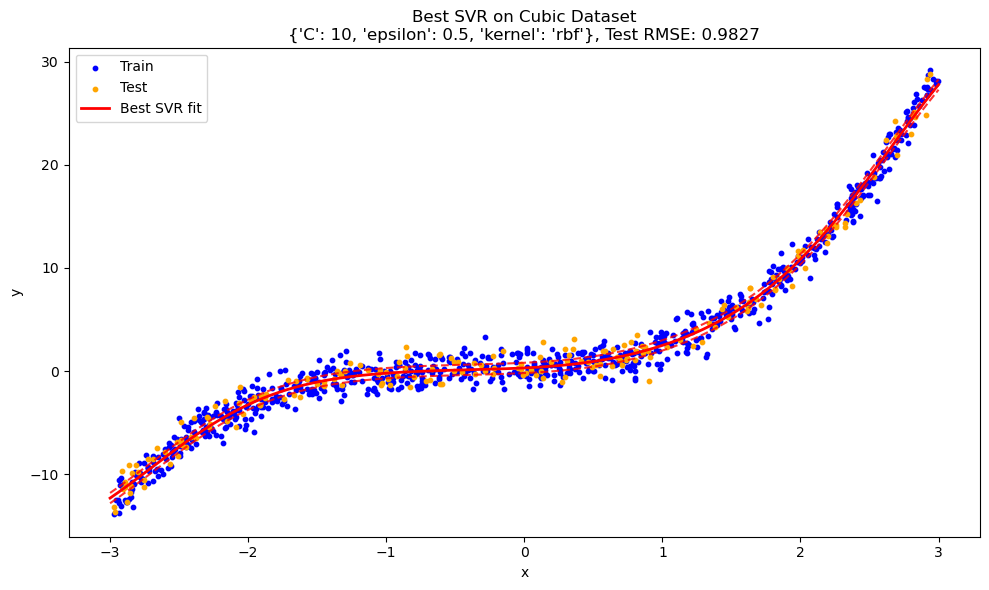

In [35]:
best_model = grid_search.best_estimator_

y_cubic_pred = best_model.predict(X_cubic_test)
test_mse = mean_squared_error(y_cubic_test, y_cubic_pred)
test_rmse = np.sqrt(test_mse)

print(f"Train MSE: {-grid_search.best_score_:.4f}")
print(f"Train RMSE: {np.sqrt(-grid_search.best_score_):.4f}")
print(f"Test MSE:  {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

x_range = np.linspace(-3, 3, 300).reshape(-1, 1)
y_range_pred = best_model.predict(x_range)
epsilon = grid_search.best_params_['epsilon']

plt.figure(figsize=(10, 6))
plt.scatter(x_cubic_train, y_cubic_train, s=10, color='blue', label='Train')
plt.scatter(x_cubic_test, y_cubic_test, s=10, color='orange', label='Test')
plt.plot(x_range, y_range_pred, color='red', linewidth=2, label='Best SVR fit')

plt.plot(x_range, y_range_pred - epsilon, 'r--', alpha=0.8)
plt.plot(x_range, y_range_pred + epsilon, 'r--', alpha=0.8)

plt.title(f"Best SVR on Cubic Dataset\n{grid_search.best_params_}, Test RMSE: {test_rmse:.4f}")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()

We can see that the best model produces a very good fit for the data, achieving a very good RMSE on the test set. `GridSearchCV` chose the `rbf` kernel over `poly`, indicating that the more flexible `rbf` was a better fit for the data over the generic `poly` kernel. 

A higher $C$ value was chosen (10 instead of 1), indicating that there was a higher penalty for misclassified training points, forcing the model to fit a more complex, narrower street. A higher value epsilon $\epsilon$ was chosen (0.5 over 0.1) suggesting that the search favoured a wider "insensitive zone", allowing more training points to fall within the street without contributing to the loss.